In [2]:
from sklearn import datasets 
from sklearn.svm import LinearSVC
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [3]:
#Load Iris datset

iris = datasets.load_iris()

x = iris["data"][: , (2 , 3)] #Petal length , Petal width
y = (iris["target"] == 2).astype(int) #Iris Virginica

In [4]:
iris_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("linear_svc" , LinearSVC(C = 1 , loss="hinge"))
])

In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
iris_pipeline.fit(x_scaled , y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [7]:
iris_pipeline.predict([[5 , 4]])

array([1])

In [8]:
#Implementing using SGDclassifier 
from sklearn.linear_model import SGDClassifier

m  = len(x)
c = 0.1

iris_pipeline_1 = Pipeline([
    ("standad_Scaler" , StandardScaler()),
    ("stiochastic " , SGDClassifier(loss= "hinge" , alpha= 1/(m*c)))
])

In [9]:
iris_pipeline_1.fit(x , y)
iris_pipeline_1.predict([[5 , 4]])

array([1])

In [10]:
#non-linear SVM classification
from sklearn.datasets import make_moons 
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


x_1 , y_1 = make_moons(n_samples=100 , random_state=42 , noise= 0.15)


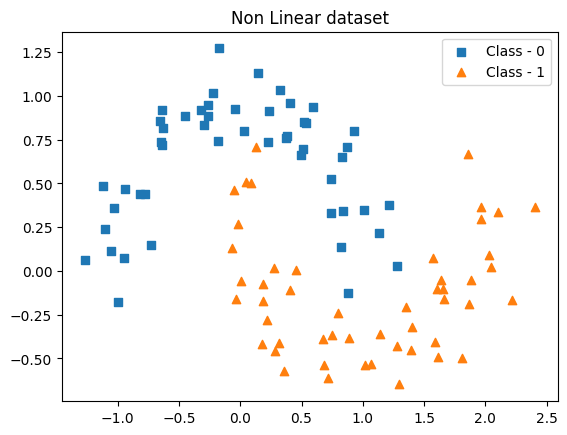

In [11]:
plt.scatter(x_1[y_1 == 0][: , 0] , x_1[y_1 == 0][: , 1] , label = "Class - 0" , marker="s")
plt.scatter(x_1[y_1 == 1][: , 0] , x_1[y_1 == 1][: , 1] , label = "Class - 1" , marker="^")
plt.title("Non Linear dataset")
plt.legend()
plt.show()

In [12]:
moon_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("poly_features" , PolynomialFeatures(degree= 3)),
    ("svm" , LinearSVC(C = 10 , loss= "hinge"))
])

moon_pipeline.fit(x_1 , y_1)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_features', PolynomialFeatures(degree=3)),
                ('svm', LinearSVC(C=10, loss='hinge'))])

In [13]:
y_pred = moon_pipeline.predict(x_1)

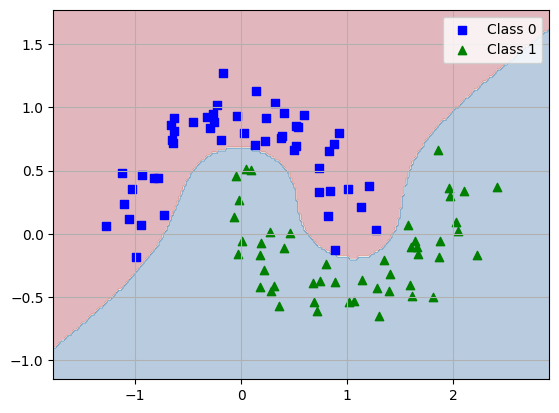

In [14]:
x_min , x_max = x_1[: , 0].min() -0.5 , x_1[: , 0].max() + 0.5
y_min , y_max = x_1[: , 1].min() -0.5 , x_1[: , 1].max() +0.5

#Meshgrid 
xx , yy = np.meshgrid(np.arange(x_min , x_max , 0.02),
                      np.arange(y_min , y_max , 0.02)) #0.02 means it returns values from x_min to x_max in the spaces of 0.02

Z = moon_pipeline.predict(np.c_[xx.ravel() , yy.ravel()])
Z = Z.reshape(xx.shape) # Plot hannu shape uniform huna parcha tesaile


plt.contourf(xx , yy , Z ,alpha = 0.3 ,cmap = "RdBu")
plt.scatter(x_1[y_pred == 0][: , 0] , x_1[y_pred == 0][: , 1] , label = "Class 0" , marker="s" , color = "blue")
plt.scatter(x_1[y_pred == 1][: , 0] , x_1[y_pred == 1][: , 1] , label = "Class 1" , marker="^" , color = "green")
plt.grid()
plt.legend()
plt.show()




In [15]:
#Polynomial Kernel :- Polynomial Kernel is a way to transform data into higher dimensions 
# implicitly without actually computing all the polynomial features. Transformarion is hidden

In [16]:
from sklearn.svm import SVC

poly_pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ("idunno" , SVC(kernel="poly" , degree= 4 , coef0=1 , C=5))
])

poly_pipeline.fit(x_1 , y_1)


Pipeline(steps=[('scaler', StandardScaler()),
                ('idunno', SVC(C=5, coef0=1, degree=4, kernel='poly'))])

In [17]:
y_pred_1 = poly_pipeline.predict(x_1)

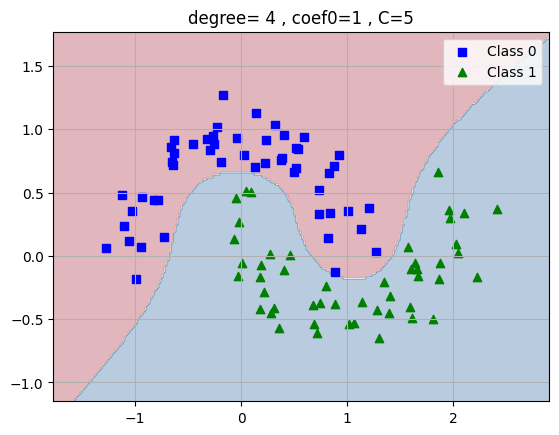

In [18]:
x1_min , x1_max = x_1[: , 0].min() - 0.5 , x_1[: , 0].max() + 0.5 
y1_min , y1_max = x_1[: , 1].min() - 0.5 , x_1[: , 1].max() + 0.5 

#Create meshgrid

xx , yy = np.meshgrid(np.arange(x1_min , x1_max , 0.02) , np.arange(y1_min , y1_max , 0.02))
Z_1 = poly_pipeline.predict(np.c_[xx.ravel() , yy.ravel()])
Z_1 = Z_1.reshape(xx.shape)

plt.contourf(xx , yy , Z_1 ,alpha = 0.3 ,cmap = "RdBu")
plt.scatter(x_1[y_pred_1 == 0][: , 0] , x_1[y_pred_1 == 0][: , 1] , label = "Class 0" , marker="s" , color = "blue")
plt.scatter(x_1[y_pred_1 == 1][: , 0] , x_1[y_pred_1 == 1][: , 1] , label = "Class 1" , marker="^" , color = "green")
plt.grid()
plt.legend()
plt.title("degree= 4 , coef0=1 , C=5")
plt.show()

In [19]:
#Gaussian RBF kernel


rbd_kernel_pipeline  = Pipeline([
    ("standard -Scaler" , StandardScaler()),
    ("rbf" , SVC(kernel= "rbf" , )) #Implicit defination
])


In [24]:
#Linear SVM regression
x = 2 * np.random.rand(100 , 1)
y = 4 + 3*x + np.random.rand(100 , 1)

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


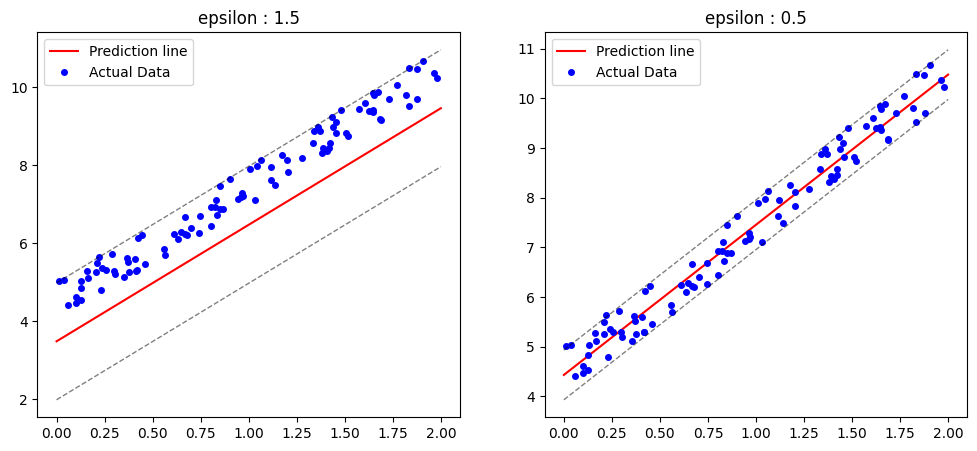

In [47]:
from sklearn.svm import LinearSVR
epsilon = [1.5 , 0.5]
subplot = [121 , 122]
plt.figure(figsize=(12, 5))

for ep , subplot_ in zip(epsilon ,subplot):
    lin = LinearSVR(epsilon= ep)
    lin.fit(x , y)
    x_new = np.linspace(0 , 2 , 200).reshape(-1 , 1)
    y_pred = lin.predict(x_new)
    plt.subplot(subplot_)
    plt.title(f"epsilon : {ep}")
    plt.plot(x_new, y_pred, "r-", label="Prediction line")
    plt.plot(x , y , "b." , label = "Actual Data" , markersize = 8)
    plt.plot(x_new , y_pred+ep , "k--" ,linewidth = 1 ,alpha = 0.5)
    plt.plot(x_new , y_pred-ep , "k--" ,linewidth = 1 ,alpha = 0.5)
    plt.legend()

In [121]:

x_pol = 6 * np.random.rand(100,1) - 3
y_pol =  x_pol**2  + x_pol + 2

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


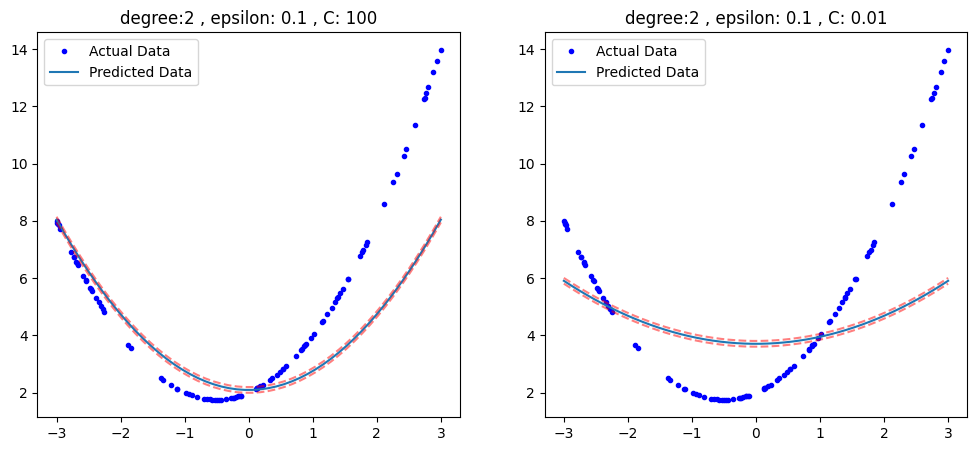

In [124]:
from sklearn.svm import SVR

c = [100 , 0.01]
plt.figure(figsize=(12, 5))

for values , subplot_ in zip(c , subplot):
    lin_svr = SVR(kernel="poly" , degree= 2 , epsilon= 0.1 , C = values)
    lin_svr.fit(x_pol , y_pol)
    x_new = np.linspace(-3 , 3).reshape(-1 , 1)
    y_prediction = lin_svr.predict(x_new)

    plt.subplot(subplot_)
    plt.plot(x_pol , y_pol , "b." , label = "Actual Data")
    plt.plot( x_new , y_prediction , label ="Predicted Data")
    plt.plot(x_new , y_prediction + 0.1 , "r--" , alpha = 0.5)
    plt.plot(x_new , y_prediction - 0.1 , "r--" , alpha = 0.5)
    plt.title(f"degree:{ 2} , epsilon: {0.1} , C: {values}")
    plt.legend()
   
    